In [1]:
import warnings
warnings.filterwarnings("ignore", message="It appears that you're using a Mac with one of Apple's ARM-based processors")

# We need to import numpyro first (though we use it last)
import numpyro
from numpyro.infer import MCMC, NUTS
from numpyro import distributions as dist
N_cores = 18
numpyro.set_host_device_count(N_cores)

from preamble_jax import *

2025-09-17 14:14:07,404 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


# A note about stats
- the arviz mcmc object contains r_hat -> this value should be 1.0 for the perfect model, a 'bad' rhat is 1.15. Less than 1.01 is one criterion people use for judging whether the models have converged. 

In [2]:
def numpyro_model():

    """
    Define the probabilistic model in NUMPYRO
    """
    params = {}

    # Stellar Parameters

    params[r'$ff_1$'] = numpyro.sample(r'$ff_1$', dist.Uniform(0, 1))
    ff_scale_factor = numpyro.sample(r'$ff_scale_factor$',dist.Uniform(0, 1))
    params[r'$ff_2$'] = numpyro.deterministic(r'$ff_2$', params[r'$ff_1$'] * ff_scale_factor )
    params[r'$ff_3$'] = numpyro.deterministic(r'$ff_3$', 1.0 - params[r'$ff_1$'] - params[r'$ff_2$'])

    params[r'$ff_1$'] = numpyro.deterministic(r'$ff_1$',  params[r'$c_1$']/(params[r'$c_1$']+params[r'$c_2$']+1.0))
    
    params[r'T$_1$'] = numpyro.sample(r'T$_1$', dist.Uniform(3900, 4400))
    params[r'T$_2$'] = numpyro.sample(r'T$_2$', dist.Uniform(3200, 3600))
    params[r'T$_3$'] = numpyro.sample(r'T$_3$', dist.Uniform(1100, 3200))

    params['offset_G102'] = numpyro.sample('offset_G102',dist.Uniform(0.3,0.4))
    offset_102 = jnp.asarray(params['offset_G102'],dtype=jnp.float64)

    params[r'$\sigma_{\rm conv}$'] = numpyro.sample(r'$\sigma_{\rm conv}$', dist.Normal(loc=0.0035,scale=0.0012))
        
    beta_102 = numpyro.sample(r'$\beta_{\rm G102}$', dist.Uniform(2.0, 2.8))
    beta_141 = numpyro.sample(r'$\beta_{\rm G141}$', dist.Uniform(2.0, 2.8))

    'Adjust and concatenate data'
    _spec_flux_jax = jnp.concatenate(
        [
            jnp.array(calibrated_mean_spec_G102+offset_102),
            jnp.array(calibrated_mean_spec_G141)
        ]
    )
    spec_flux_jax = _spec_flux_jax/jnp.mean(_spec_flux_jax)
    spec_err_jax = jnp.concatenate(
        [
            jnp.array((10**beta_102)*oot_spec_err_G102),
            jnp.array((10**beta_141)*oot_spec_err_G141)
        ]
    )
    combined_SED_wavelengths = jnp.concatenate([jnp.array(SED_wavelengths_G102),jnp.array(SED_wavelengths_G141)])
    
    @jit
    def decomp_model(params,data_wave,**kwargs):

        f_1 = jnp.asarray(params[r'$ff_1$'], dtype=jnp.float64)
        f_2 = jnp.asarray(params[r'$ff_2$'], dtype=jnp.float64)
        f_3 = jnp.asarray(params[r'$ff_3$'], dtype=jnp.float64)
        
        T_1 = jnp.asarray(params['T$_1$'], dtype=jnp.float64)
        T_2 = jnp.asarray(params['T$_2$'], dtype=jnp.float64)
        T_3 = jnp.asarray(params['T$_3$'], dtype=jnp.float64)
        
        spec_1, spec_2, spec_3, = [
            get_BTSettl_spectrum_jax(T=Temp)
            for Temp in [T_1,T_2,T_3] ]
        
        # Calculate combined spectrum
        _f = (f_1*spec_1[1] + f_2*spec_2[1] + f_3*spec_3[1] )
        _model_flux = ( _f/jnp.mean(_f) )
        convolved = convolve_spectrum_jax( panchromatic_wavelengths, _model_flux, sigma=jnp.asarray(params[r'$\sigma_{\rm conv}$'], dtype=jnp.float64) )
        binned_model_flux = shone.bin_spectrum(data_wave, panchromatic_wavelengths, convolved)
        model_flux = (binned_model_flux/jnp.mean(binned_model_flux))

        return model_flux

    numpyro.sample(
        "Obs", dist.Normal(
            loc=decomp_model(params,combined_SED_wavelengths), 
            scale=spec_err_jax,
        ), obs=spec_flux_jax
    )

🌈🤖 The time scale for this rainbow is '?',
and there are 160 time centers and
160 time edges defined.

It's hard to imshow something with a time axis
that isn't linearly or logarithmically uniform, or doesn't
at least have its time edges defined. We're giving up
and just using the time index as the time axis.

If you want a real time axis, one solution would be
to use `rainbow.pcolormesh()` instead of `rainbow.imshow()`.
It takes basically the same inputs but can handle non-uniform
grids.

Or, you could bin your times to a more uniform grid with
`binned = rainbow.bin(dt=...)` (for linear times) and then
`binned.imshow()` will give more informative axes.



  0%|          | 0/132 [00:00<?, ?it/s]

  0%|          | 0/112 [00:00<?, ?it/s]

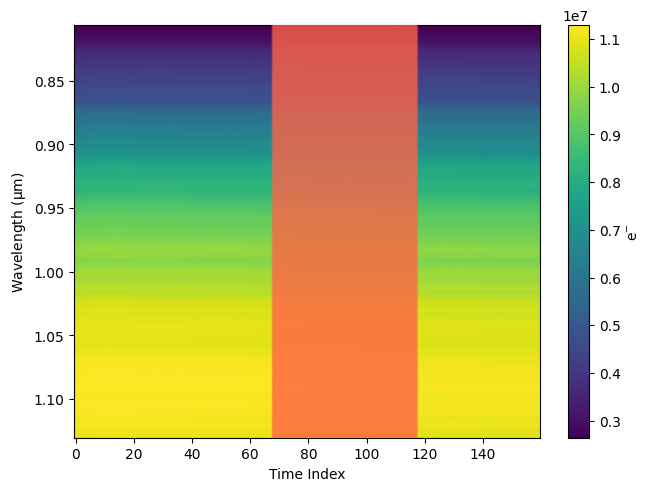

In [3]:
visit = 'S22'

bin_edges = S22_speclc_bin_edges 
err_factor = S22_SED_err_factor
speclc_err_factor = S22_speclc_err_factor

'Things that automatically get re-defined for either visit'
predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
rainbow = read_rainbow(f"../data/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
speclc_rainbow = rainbow

'Adjust uncertainties and bin the rainbow'
for i in range(len(rainbow.wavelength.value)):
    speclc_rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] * err_factor[i]

'remove the transit'
out_of_transit = ( speclc_rainbow.trim().mask_transit(period=8.463*u.day, t0=predicted_T0*u.day, duration=0.15*u.day) )

out_of_transit.imshow()
'define the appropriate arrays'
_meanOOTspec = out_of_transit.get_average_spectrum_as_rainbow()
meanOOTspec = _meanOOTspec.flux
meanOOTspec_relative_err = _meanOOTspec.uncertainty.value/meanOOTspec.value
oot_spec_err = meanOOTspec_relative_err.flatten()
_SED_wavelengths = (_meanOOTspec.wavelength.value).flatten()
e_per_s = meanOOTspec / exptime
e_per_s_per_angstrom = e_per_s / binwidth
_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=_SED_wavelengths)['y'] * u.cm**2 / u.erg
_calibrated_mean_spec = e_per_s_per_angstrom.flatten() / binned_filter_response
calibrated_mean_spec = _calibrated_mean_spec.value/np.nanmean(_calibrated_mean_spec.value)
oot_spec_err = oot_spec_err * calibrated_mean_spec

# Convert to JAX arrays
calibrated_mean_spec_G102 = jnp.array(calibrated_mean_spec)
oot_spec_err_G102 = jnp.array(oot_spec_err)
SED_wavelengths_G102 = jnp.array(_SED_wavelengths)

# plt.errorbar(SED_wavelengths_G102,calibrated_mean_spec_G102,yerr=oot_spec_err_G102*200,fmt='o')

visit = 'F21'

bin_edges = F21_speclc_bin_edges 
err_factor = F21_SED_err_factor
speclc_err_factor = F21_speclc_err_factor

'Things that automatically get re-defined for either visit'
predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
rainbow = read_rainbow(f"../data/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
speclc_rainbow = rainbow

'Adjust uncertainties and bin the rainbow'
for i in range(len(rainbow.wavelength.value)):
    speclc_rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] * err_factor[i]

'remove the transit'
out_of_transit = ( speclc_rainbow.trim().mask_transit(period=8.463*u.day, t0=predicted_T0*u.day, duration=0.15*u.day) )

'define the appropriate arrays'
_meanOOTspec = out_of_transit.get_average_spectrum_as_rainbow()
meanOOTspec = _meanOOTspec.flux
meanOOTspec_relative_err = _meanOOTspec.uncertainty.value/meanOOTspec.value
_oot_spec_err = meanOOTspec_relative_err.flatten()
_SED_wavelengths = (_meanOOTspec.wavelength.value).flatten()
e_per_s = meanOOTspec / exptime
e_per_s_per_angstrom = e_per_s / binwidth
_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=_SED_wavelengths)['y'] * u.cm**2 / u.erg
_calibrated_mean_spec = e_per_s_per_angstrom.flatten() / binned_filter_response
calibrated_mean_spec = _calibrated_mean_spec.value/np.nanmean(_calibrated_mean_spec.value)
oot_spec_err = _oot_spec_err * calibrated_mean_spec

# Convert to JAX arrays
calibrated_mean_spec_G141 = jnp.array(calibrated_mean_spec)
oot_spec_err_G141 = jnp.array(oot_spec_err)
SED_wavelengths_G141 = jnp.array(_SED_wavelengths)

# plt.errorbar(SED_wavelengths_G141,calibrated_mean_spec_G141,yerr=oot_spec_err_G141*200,fmt='o')

In [5]:
n_temps = 3
n_warmup = 1_00
n_samples = 1_000
n_chains = 14 # 14, 11, 9, 7, 6, 5

model_designation = f'jointvisit_{n_temps}T_{n_samples}_{n_chains}chains_SED_final'

  0%|          | 0/3 [00:00<?, ?it/s]




Begin warmup





  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Corner for checkpoint 0


/opt/anaconda3/envs/fleckopy/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


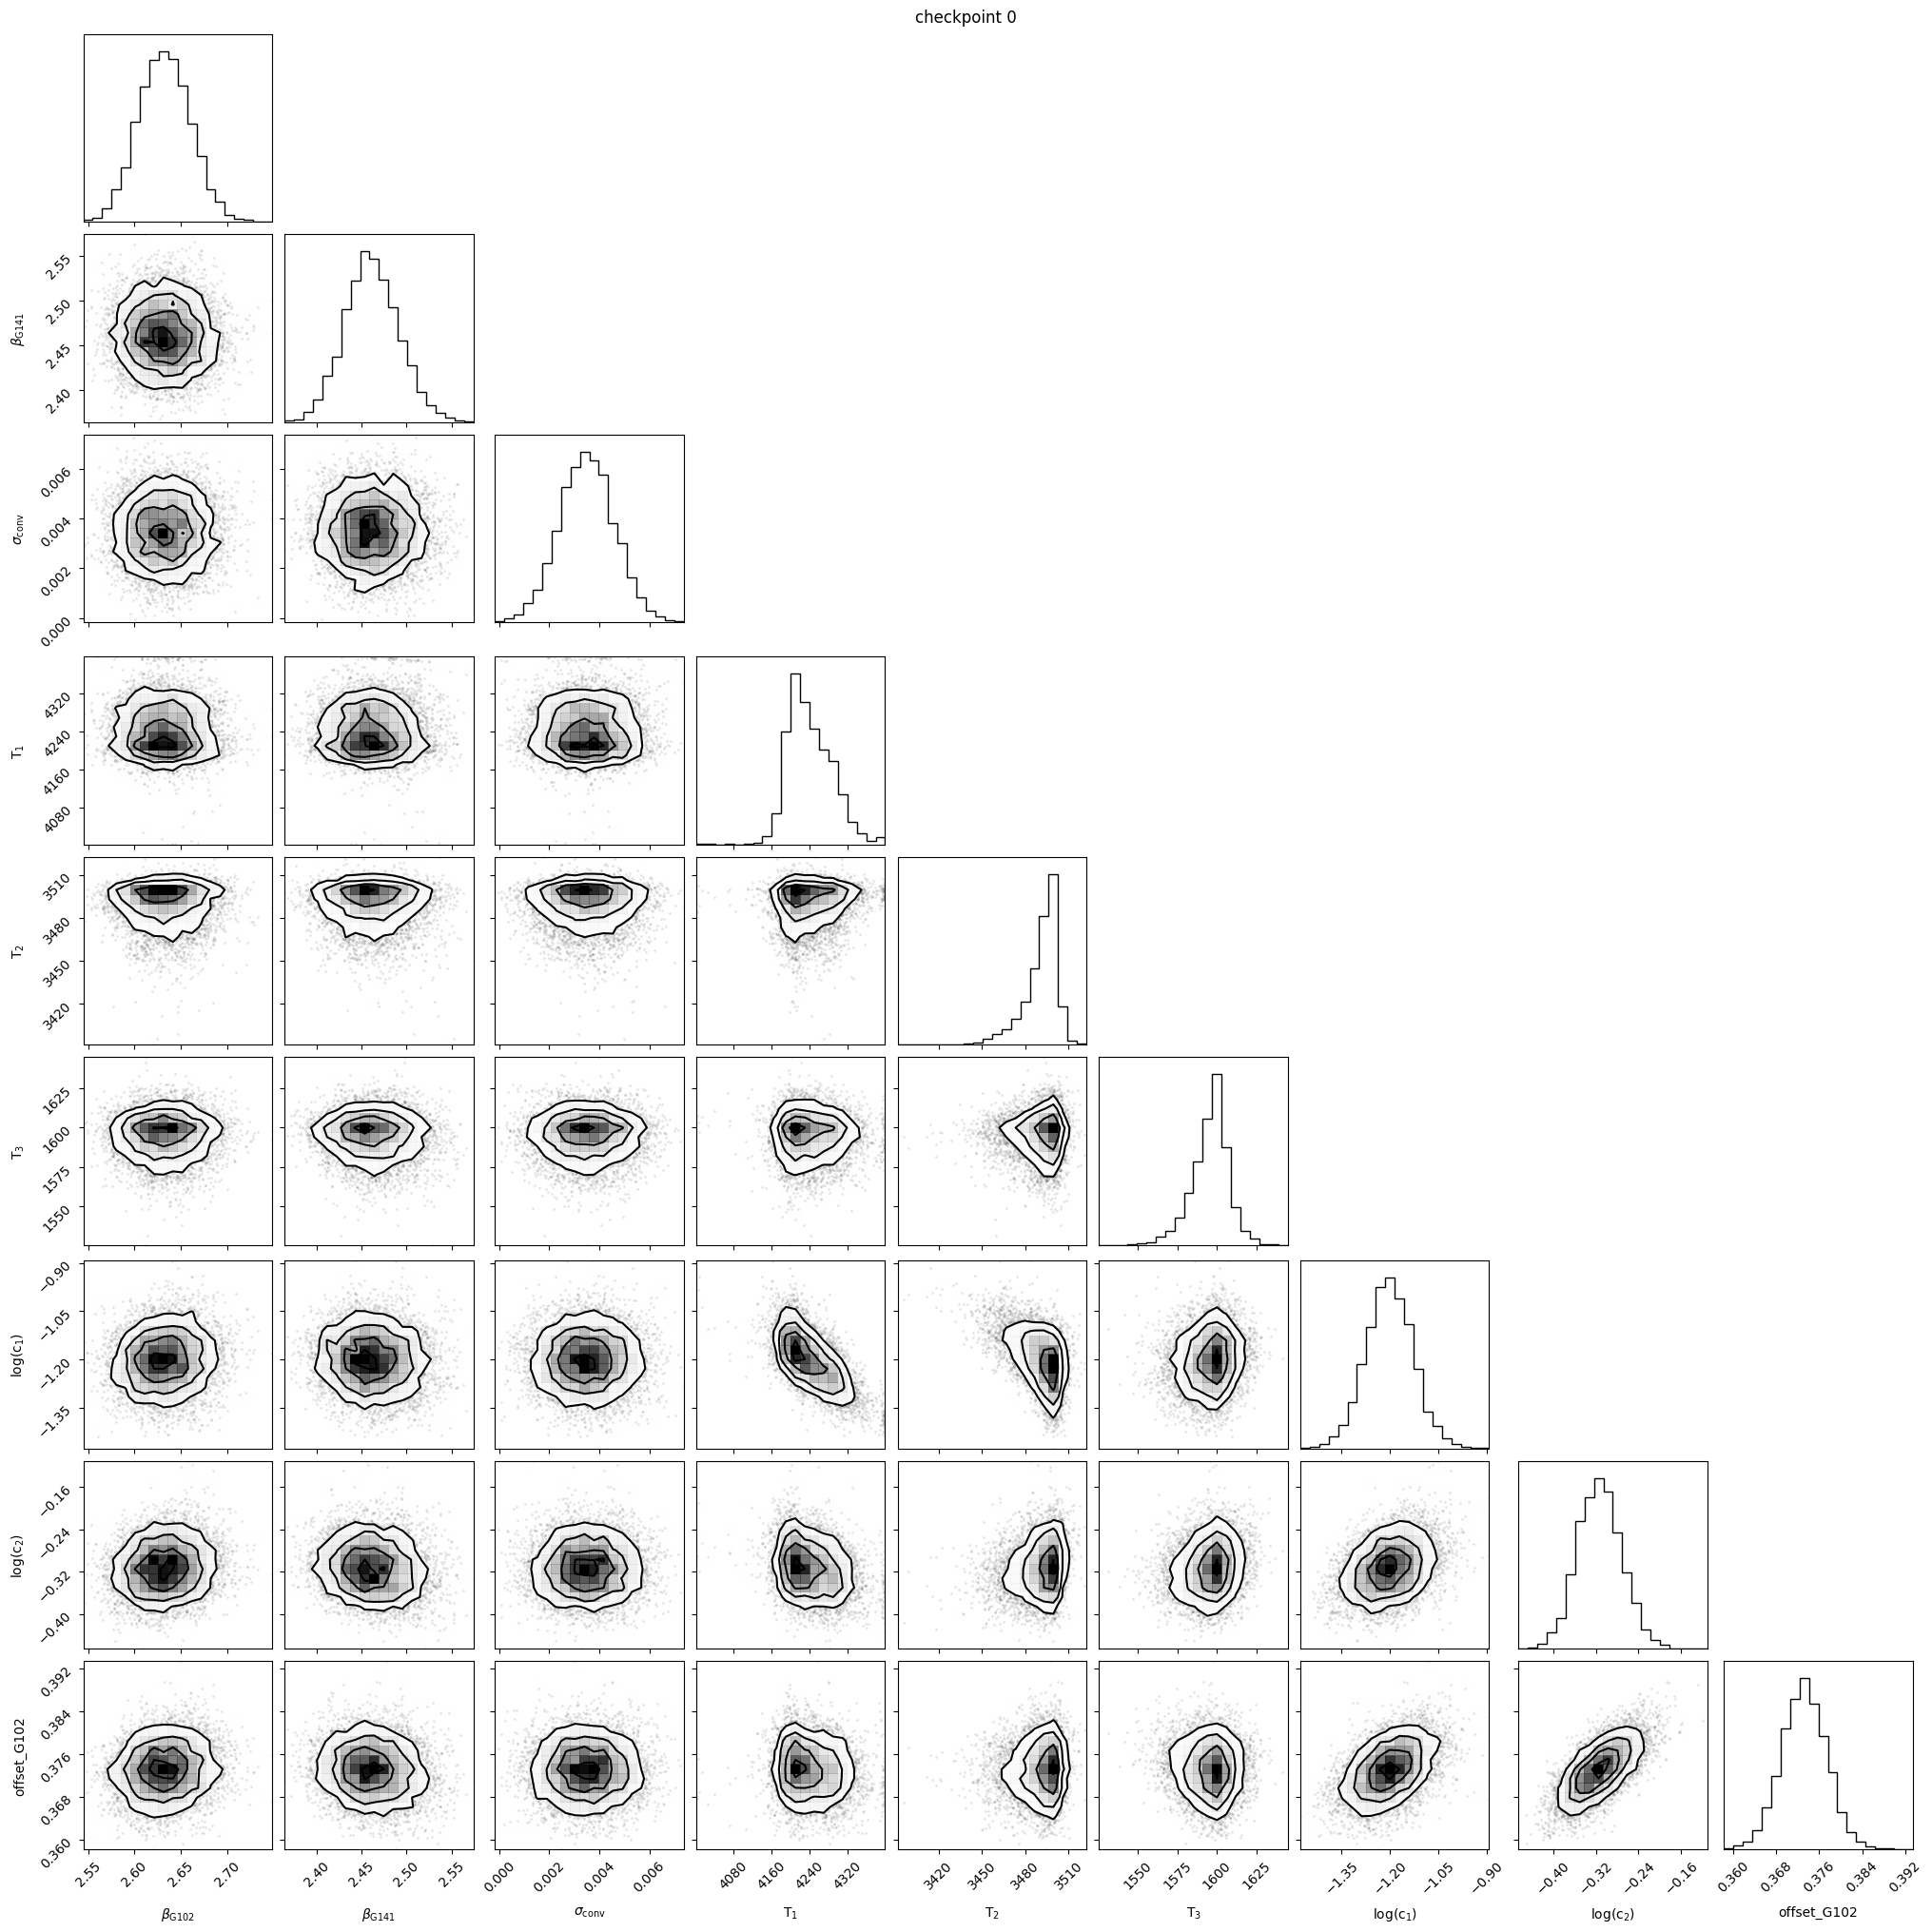

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
rng_key = PRNGKey(10)

sampler = NUTS(
    numpyro_model,
    dense_mass=True)

mcmc = MCMCWithCheckpoints(
    sampler, 
    num_warmup=n_warmup, 
    num_samples=n_samples,
    num_chains=n_chains
)

mcmc.run_checkpoints(rng_key, n_checkpoints=2, on_checkpoint=post_batch_viz_save)

mcmc.print_summary()                                                                        

# arviz converts a numpyro MCMC object to an `InferenceData` object based on xarray:
result = arviz.from_numpyro(mcmc)

# Post-Inference Analysis

In [ ]:
'Save the result'
result.to_netcdf(f'../data/samples/{model_designation}')

'Print the summary'
arviz.summary(result)

In [ ]:
'Examine the Leave-One-Out (LOO) summary'
loo = arviz.loo(result, pointwise=True)
loo

In [ ]:
'List the points which should be trimmed'

In [ ]:
'Extract median result'
median_params = arviz.summary(result,stat_focus='median')['median']

In [ ]:
'Make a corner plot'
corner.corner(
    result, var_names=['~offset_G102',
                       r'~$\beta_{\rm G102}$',
                       r'~$\beta_{\rm G141}$',
                       r'~$\sigma_{\rm conv}$'],
    # quiet=True, 
);
plt.savefig(f'../figs/{model_designation}_corner.png',dpi=200)

In [ ]:
'Plot the data, model, and residuals'

_spec_flux_jax = jnp.concatenate([jnp.array(calibrated_mean_spec_G102+jnp.asarray(median_params['offset_G102'],dtype=jnp.float64)),
                                         jnp.array(calibrated_mean_spec_G141)])
median_spec_flux = _spec_flux_jax/jnp.mean(_spec_flux_jax)
median_spec_err = jnp.concatenate([jnp.array(oot_spec_err_G102*jnp.asarray(10**median_params[r'$\beta_{\rm G102}$'],dtype=jnp.float64)),
                                jnp.array(oot_spec_err_G141*jnp.asarray(10**median_params[r'$\beta_{\rm G141}$'],dtype=jnp.float64))])
combined_SED_wavelengths = jnp.concatenate([jnp.array(SED_wavelengths_G102),jnp.array(SED_wavelengths_G141)])

filter_sigma = jnp.asarray(median_params[r'$\sigma_{\rm conv}$'], dtype=jnp.float64)
T_1 = jnp.asarray(median_params['T$_1$'], dtype=jnp.float64)
T_2 = jnp.asarray(median_params['T$_2$'], dtype=jnp.float64)
T_3 = jnp.asarray(median_params['T$_3$'], dtype=jnp.float64)

spec_1, spec_2, spec_3, = [
    get_BTSettl_spectrum_jax(T=Temp)
    for Temp in [T_1,T_2,T_3] ]

c1 = jnp.asarray(10**median_params[r'log(c$_1$)'],dtype=jnp.float64)
c2 = jnp.asarray(10**median_params[r'log(c$_2$)'],dtype=jnp.float64)
c3 = 1.0
_median_flux = (c1*spec_1[1] + c2*spec_2[1] + c3*spec_3[1])
_model_flux = _median_flux/jnp.mean(_median_flux)
convolved = convolve_spectrum_jax(panchromatic_wavelengths, _model_flux, sigma=filter_sigma)
binned_model_flux = shone.bin_spectrum(combined_SED_wavelengths, panchromatic_wavelengths, convolved)
median_model_flux = (binned_model_flux/jnp.mean(binned_model_flux))

fig,axs = plt.subplots(2,1,figsize=(12,8),sharex=True,gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle(r'0.8-1.65 $\mu$m SED with '+f'{n_temps}T Model',fontsize=20)
axs[1].set_title('Residuals',fontsize=14)
axs[1].set_xlim(0.805,1.645)
axs[1].set_ylim(-4,4)
axs[1].set_xlabel(r'Wavelength ($\mu$m)',fontsize=14)
axs[0].set_ylabel('Relative Flux',fontsize=14)
axs[1].set_ylabel(r'$\sigma$',fontsize=14)

axs[0].errorbar(combined_SED_wavelengths,
                median_spec_flux,
                yerr=median_spec_err,
                fmt='o',color='b',ms=1,alpha=0.7)
axs[0].plot(combined_SED_wavelengths,
                median_model_flux,color='k',zorder=100)
axs[1].scatter(combined_SED_wavelengths,(median_model_flux-median_spec_flux)/median_spec_err,color='gray')

plt.savefig(f'../figs/{model_designation}_result.png',dpi=200)

# Compare multiple models of the same dataset

In [ ]:
compare_dict = {}

compare_dict['model_1'] = arviz.InferenceData.from_netcdf('../data/samples/jointvisit_3T_1000_11chains_SED_separatebetas')
compare_dict['model_2'] = arviz.InferenceData.from_netcdf('../data/samples/jointvisit_3T_1000_14chains_SED_photonerrs')
# compare_dict['model_3'] = arviz.InferenceData.from_netcdf('../data/samples/')

arviz.compare(compare_dict)

From https://num.pyro.ai/en/latest/tutorials/bad_posterior_geometry.html

In general it is difficult to assess whether the samples returned from HMC or NUTS represent accurate (approximate) samples from the posterior. Two general rules of thumb, however, are to look at the effective sample size (ESS) and r_hat diagnostics returned by mcmc.print_summary(). If we see values of r_hat in the range (1.0, 1.05) and effective sample sizes that are comparable to the total number of samples num_samples (assuming thinning=1) then we have good reason to believe that HMC is doing a good job. If, however, we see low effective sample sizes or large r_hats for some of the variables (e.g. r_hat = 1.15) then HMC is likely struggling with the posterior geometry. In the following we will use r_hat as our primary diagnostic metric.